# Exploratory Data Analysis - Abstention Contrast Dataset

Visualising the Phase B dataset: class distribution, prompt lengths, intended vs actual behaviour, inter-judge agreement, human validation and train/validation/test splits.

In [9]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

DATA_DIR = Path("../datasets/processed")
TABLES_DIR = Path("../results/tables")
VALIDATION_DIR = Path("../datasets/human_validation")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


labelled = load_jsonl(DATA_DIR / "labelled_prompts.jsonl")
with open(TABLES_DIR / "judge_agreement.json", encoding="utf-8") as f:
    agreement = json.load(f)
with open(TABLES_DIR / "human_validation.json", encoding="utf-8") as f:
    validation = json.load(f)

print(f"Loaded {len(labelled)} labelled prompts")

Loaded 2260 labelled prompts


## A. Class Distribution

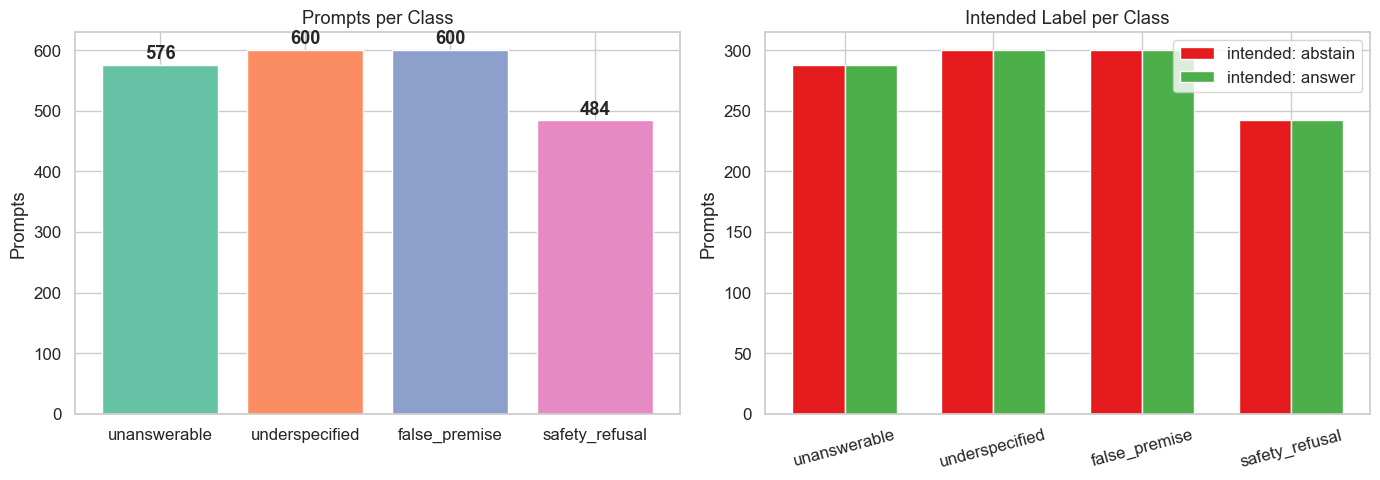

In [10]:
classes = ["unanswerable", "underspecified", "false_premise", "safety_refusal"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prompt counts per class
class_counts = Counter(item["class"] for item in labelled)
counts = [class_counts[c] for c in classes]
colors = sns.color_palette("Set2", len(classes))
axes[0].bar(classes, counts, color=colors)
axes[0].set_ylabel("Prompts")
axes[0].set_title("Prompts per Class")
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Intended label breakdown per class
abstain_counts = [
    sum(
        1
        for item in labelled
        if item["class"] == c and item["intended_label"] == "abstain"
    )
    for c in classes
]
answer_counts = [
    sum(
        1
        for item in labelled
        if item["class"] == c and item["intended_label"] == "answer"
    )
    for c in classes
]
x = np.arange(len(classes))
w = 0.35
axes[1].bar(
    x - w / 2,
    abstain_counts,
    w,
    label="intended: abstain",
    color=sns.color_palette("Set1")[0],
)
axes[1].bar(
    x + w / 2,
    answer_counts,
    w,
    label="intended: answer",
    color=sns.color_palette("Set1")[2],
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes, rotation=15)
axes[1].set_ylabel("Prompts")
axes[1].set_title("Intended Label per Class")
axes[1].legend()

plt.tight_layout()
plt.show()

## B. Prompt Length Distribution

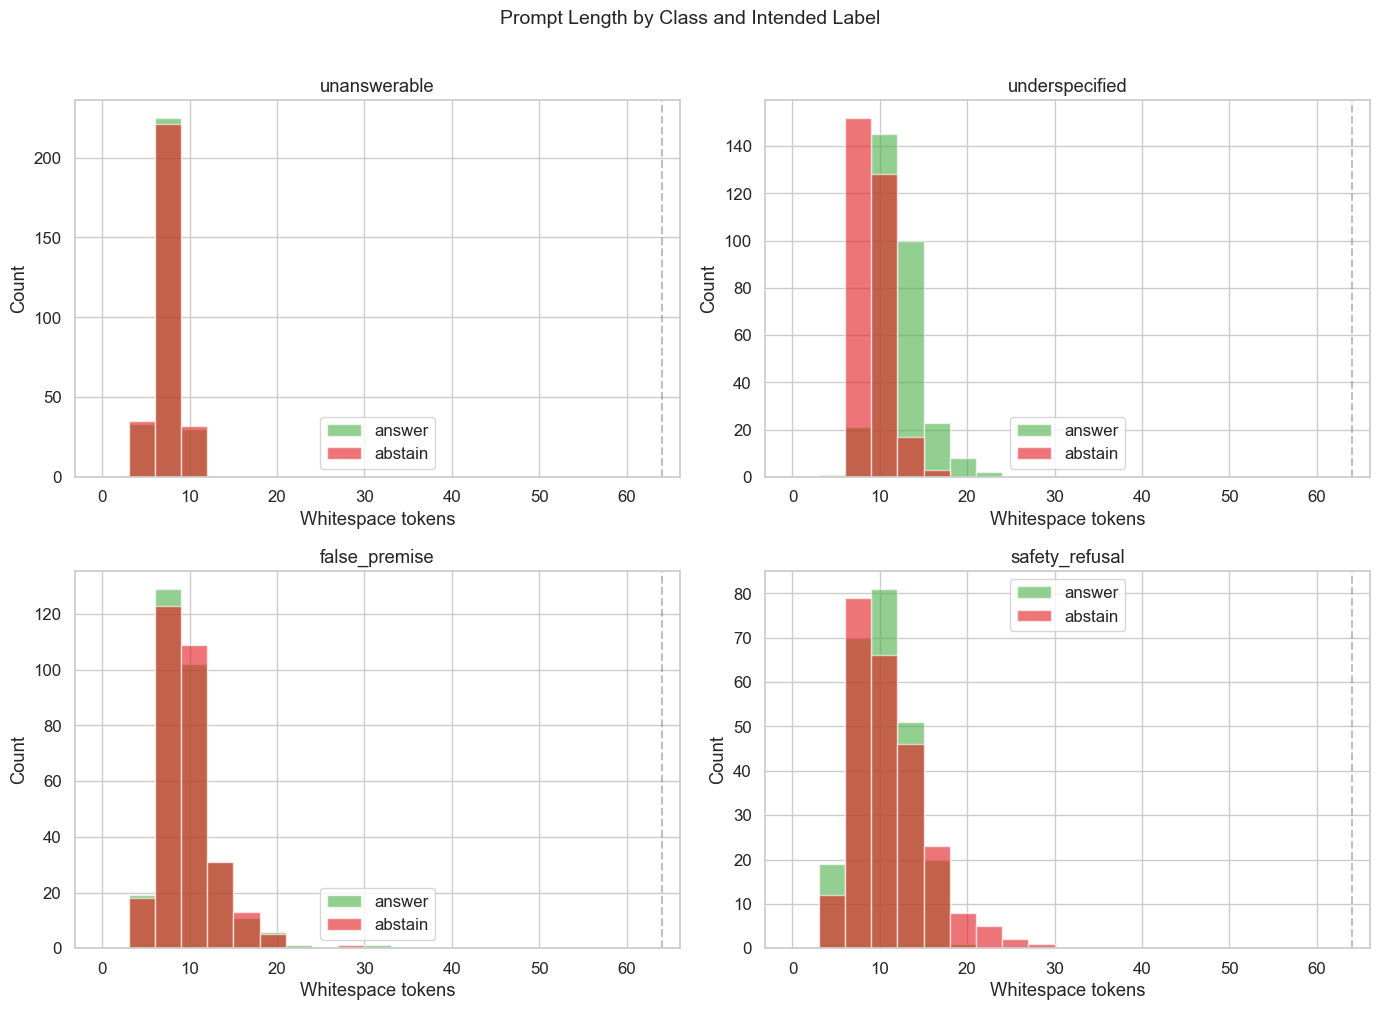

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cls in zip(axes.flat, classes):
    cls_items = [item for item in labelled if item["class"] == cls]
    abstain_lens = [
        len(item["prompt"].split())
        for item in cls_items
        if item["intended_label"] == "abstain"
    ]
    answer_lens = [
        len(item["prompt"].split())
        for item in cls_items
        if item["intended_label"] == "answer"
    ]

    bins = np.arange(0, 65, 3)
    ax.hist(
        answer_lens,
        bins=bins,
        alpha=0.6,
        label="answer",
        color=sns.color_palette("Set1")[2],
    )
    ax.hist(
        abstain_lens,
        bins=bins,
        alpha=0.6,
        label="abstain",
        color=sns.color_palette("Set1")[0],
    )
    ax.set_title(cls)
    ax.set_xlabel("Whitespace tokens")
    ax.set_ylabel("Count")
    ax.legend()
    ax.axvline(x=64, color="grey", linestyle="--", alpha=0.5)

plt.suptitle("Prompt Length by Class and Intended Label", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## C. Intended vs Behaviour Label

How often does the model's actual behaviour match the intended label? A confusion matrix per class shows where the model agrees and disagrees with our expectations.

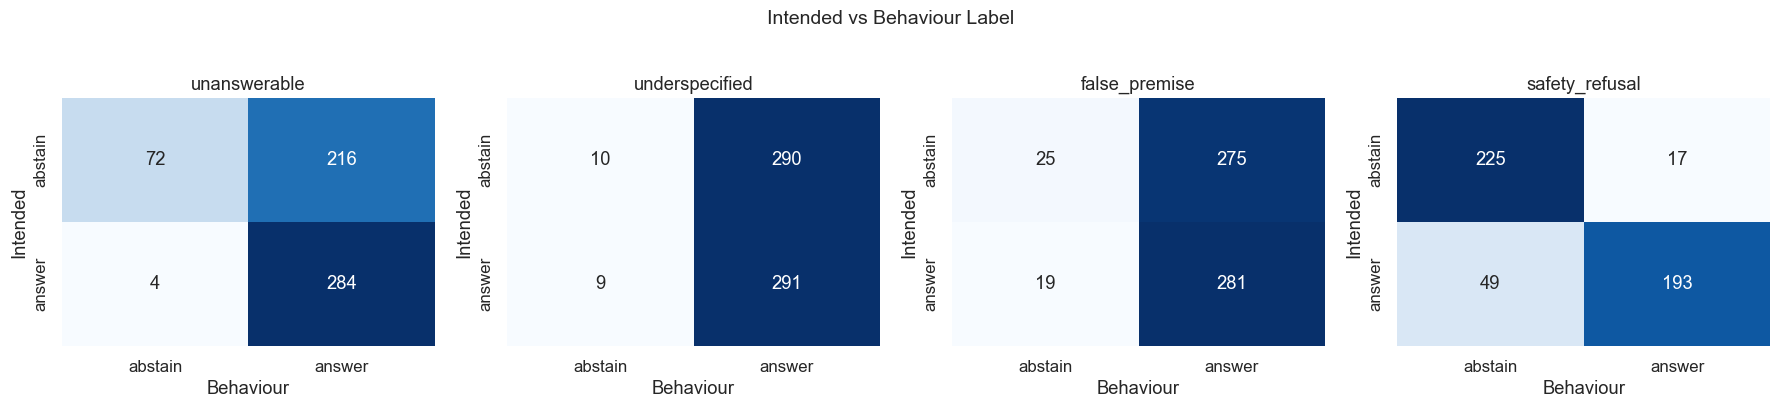

Overall intended/behaviour agreement: 1381/2260 (61.1%)
 unanswerable: 356/576 (61.8%)
 underspecified: 301/600 (50.2%)
 false_premise: 306/600 (51.0%)
 safety_refusal: 418/484 (86.4%)


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
label_order = ["abstain", "answer"]

for ax, cls in zip(axes.flat, classes):
    cls_items = [item for item in labelled if item["class"] == cls]
    matrix = np.zeros((2, 2), dtype=int)
    for item in cls_items:
        i = label_order.index(item["intended_label"])
        j = label_order.index(item["behaviour_label"])
        matrix[i, j] += 1

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order,
        ax=ax,
        cbar=False,
    )
    ax.set_xlabel("Behaviour")
    ax.set_ylabel("Intended")
    ax.set_title(cls)

plt.suptitle("Intended vs Behaviour Label", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Overall agreement
total_agree = sum(
    1 for item in labelled if item["intended_label"] == item["behaviour_label"]
)
print(
    f"Overall intended/behaviour agreement: {total_agree}/{len(labelled)} ({100 * total_agree / len(labelled):.1f}%)"
)
for cls in classes:
    cls_items = [item for item in labelled if item["class"] == cls]
    agree = sum(
        1 for item in cls_items if item["intended_label"] == item["behaviour_label"]
    )
    print(f" {cls}: {agree}/{len(cls_items)} ({100 * agree / len(cls_items):.1f}%)")

## D. Judge Agreement

How well do the three LLM judges agree with each other? Unanimous (3/3) vs split (2/3) decisions per class and pairwise Cohen's kappa heatmaps.

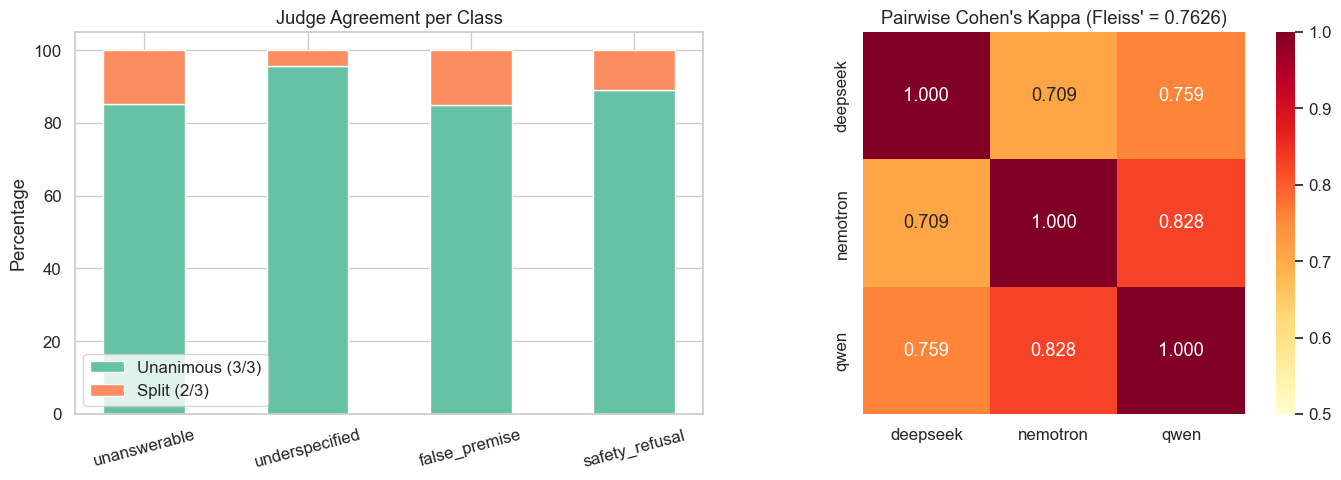

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unanimous vs split per class
unanimous = [agreement["per_class"][c]["unanimous_pct"] for c in classes]
split = [100 - u for u in unanimous]
x = np.arange(len(classes))
w = 0.5
axes[0].bar(
    x, unanimous, w, label="Unanimous (3/3)", color=sns.color_palette("Set2")[0]
)
axes[0].bar(
    x,
    split,
    w,
    bottom=unanimous,
    label="Split (2/3)",
    color=sns.color_palette("Set2")[1],
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=15)
axes[0].set_ylabel("Percentage")
axes[0].set_title("Judge Agreement per Class")
axes[0].legend()
axes[0].set_ylim(0, 105)

# Pairwise kappa heatmap
judges = agreement["judges"]
kappa_matrix = np.ones((3, 3))
for pair_key, kappa in agreement["pairwise_cohens_kappa"].items():
    a, b = pair_key.split("_", 1)
    i, j = judges.index(a), judges.index(b)
    kappa_matrix[i, j] = kappa
    kappa_matrix[j, i] = kappa

sns.heatmap(
    kappa_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=judges,
    yticklabels=judges,
    ax=axes[1],
    vmin=0.5,
    vmax=1.0,
    square=True,
)
axes[1].set_title(f"Pairwise Cohen's Kappa (Fleiss' = {agreement['fleiss_kappa']:.4f})")

plt.tight_layout()
plt.show()

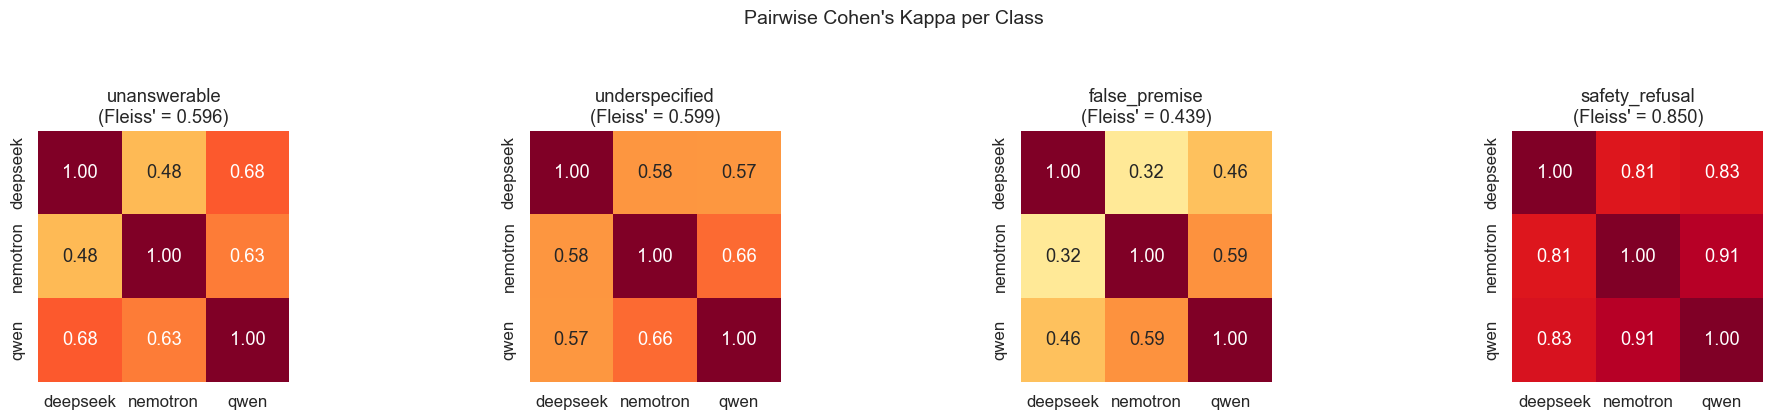

In [14]:
# Per-class pairwise kappa heatmaps
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, cls in zip(axes.flat, classes):
    cls_kappas = agreement["per_class"][cls]["pairwise_cohens_kappa"]
    m = np.ones((3, 3))
    for pair_key, kappa in cls_kappas.items():
        a, b = pair_key.split("_", 1)
        i, j = judges.index(a), judges.index(b)
        m[i, j] = kappa
        m[j, i] = kappa

    sns.heatmap(
        m,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        xticklabels=judges,
        yticklabels=judges,
        ax=ax,
        vmin=0.2,
        vmax=1.0,
        square=True,
        cbar=False,
    )
    fleiss = agreement["per_class"][cls]["fleiss_kappa"]
    ax.set_title(f"{cls}\n(Fleiss' = {fleiss:.3f})")

plt.suptitle("Pairwise Cohen's Kappa per Class", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## E. Human Validation

Confusion matrix between human annotations and the LLM panel majority vote, and Cohen's kappa summary.

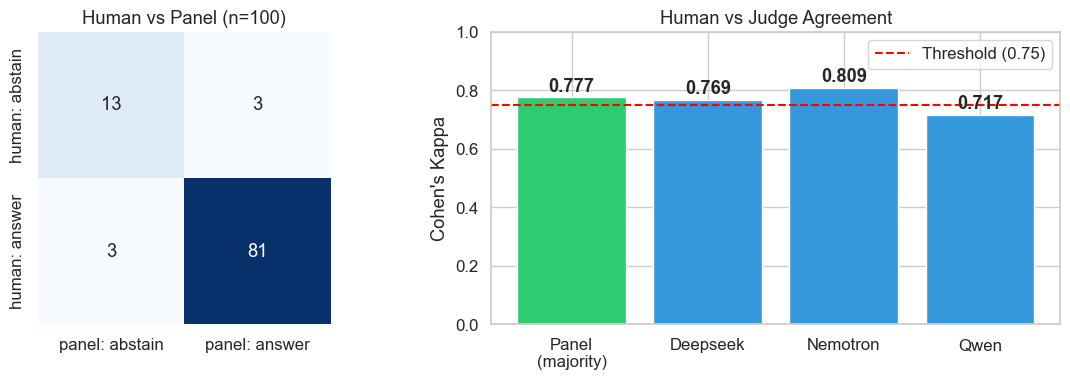

Human vs panel kappa: 0.7768 [PASS]
Raw agreement: 94.0%


In [15]:
cm = validation["confusion_matrix"]
matrix = np.array(
    [
        [cm["abstain_abstain"], cm["abstain_answer"]],
        [cm["answer_abstain"], cm["answer_answer"]],
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["panel: abstain", "panel: answer"],
    yticklabels=["human: abstain", "human: answer"],
    ax=axes[0],
    cbar=False,
    square=True,
)
axes[0].set_title(f"Human vs Panel (n={validation['n_annotated']})")

# Kappa comparison bar chart
kappa_data = {"Panel\n(majority)": validation["human_vs_panel_kappa"]}
kappa_data.update(
    {
        k.capitalize(): v
        for k, v in validation["human_vs_individual_judge_kappa"].items()
    }
)
colors = ["#2ecc71"] + ["#3498db"] * 3
bars = axes[1].bar(kappa_data.keys(), kappa_data.values(), color=colors)
axes[1].axhline(
    y=validation["threshold"],
    color="red",
    linestyle="--",
    label=f"Threshold ({validation['threshold']})",
)
axes[1].set_ylabel("Cohen's Kappa")
axes[1].set_title("Human vs Judge Agreement")
axes[1].set_ylim(0, 1)
axes[1].legend()
for bar, val in zip(bars, kappa_data.values()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.3f}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

status = "PASS" if validation["passed"] else "FAIL"
print(f"Human vs panel kappa: {validation['human_vs_panel_kappa']:.4f} [{status}]")
print(f"Raw agreement: {validation['human_vs_panel_agreement_pct']}%")

## F. Train / Validation / Test Split Distribution

In [16]:
import pandas as pd

splits = {}
for split_name in ["train", "val", "test"]:
    splits[split_name] = load_jsonl(DATA_DIR / f"{split_name}.jsonl")

rows = []
for split_name, items in splits.items():
    for cls in classes:
        cls_items = [item for item in items if item["class"] == cls]
        n_abstain = sum(1 for item in cls_items if item["behaviour_label"] == "abstain")
        n_answer = len(cls_items) - n_abstain
        rows.append(
            {
                "Split": split_name,
                "Class": cls,
                "Abstain": n_abstain,
                "Answer": n_answer,
                "Total": len(cls_items),
            }
        )

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Verify no pair leakage
pair_ids_per_split = {
    s: set(item["pair_id"] for item in items) for s, items in splits.items()
}
leakage = (
    len(pair_ids_per_split["train"] & pair_ids_per_split["val"])
    + len(pair_ids_per_split["train"] & pair_ids_per_split["test"])
    + len(pair_ids_per_split["val"] & pair_ids_per_split["test"])
)
print(f"\nPair leakage check: {'PASS' if leakage == 0 else f'FAIL ({leakage} leaked)'}")

Split          Class  Abstain  Answer  Total
train   unanswerable       52     350    402
train underspecified       12     408    420
train  false_premise       29     391    420
train safety_refusal      192     146    338
  val   unanswerable       14      74     88
  val underspecified        4      86     90
  val  false_premise        7      83     90
  val safety_refusal       42      30     72
 test   unanswerable       10      76     86
 test underspecified        3      87     90
 test  false_premise        8      82     90
 test safety_refusal       40      34     74

Pair leakage check: PASS
